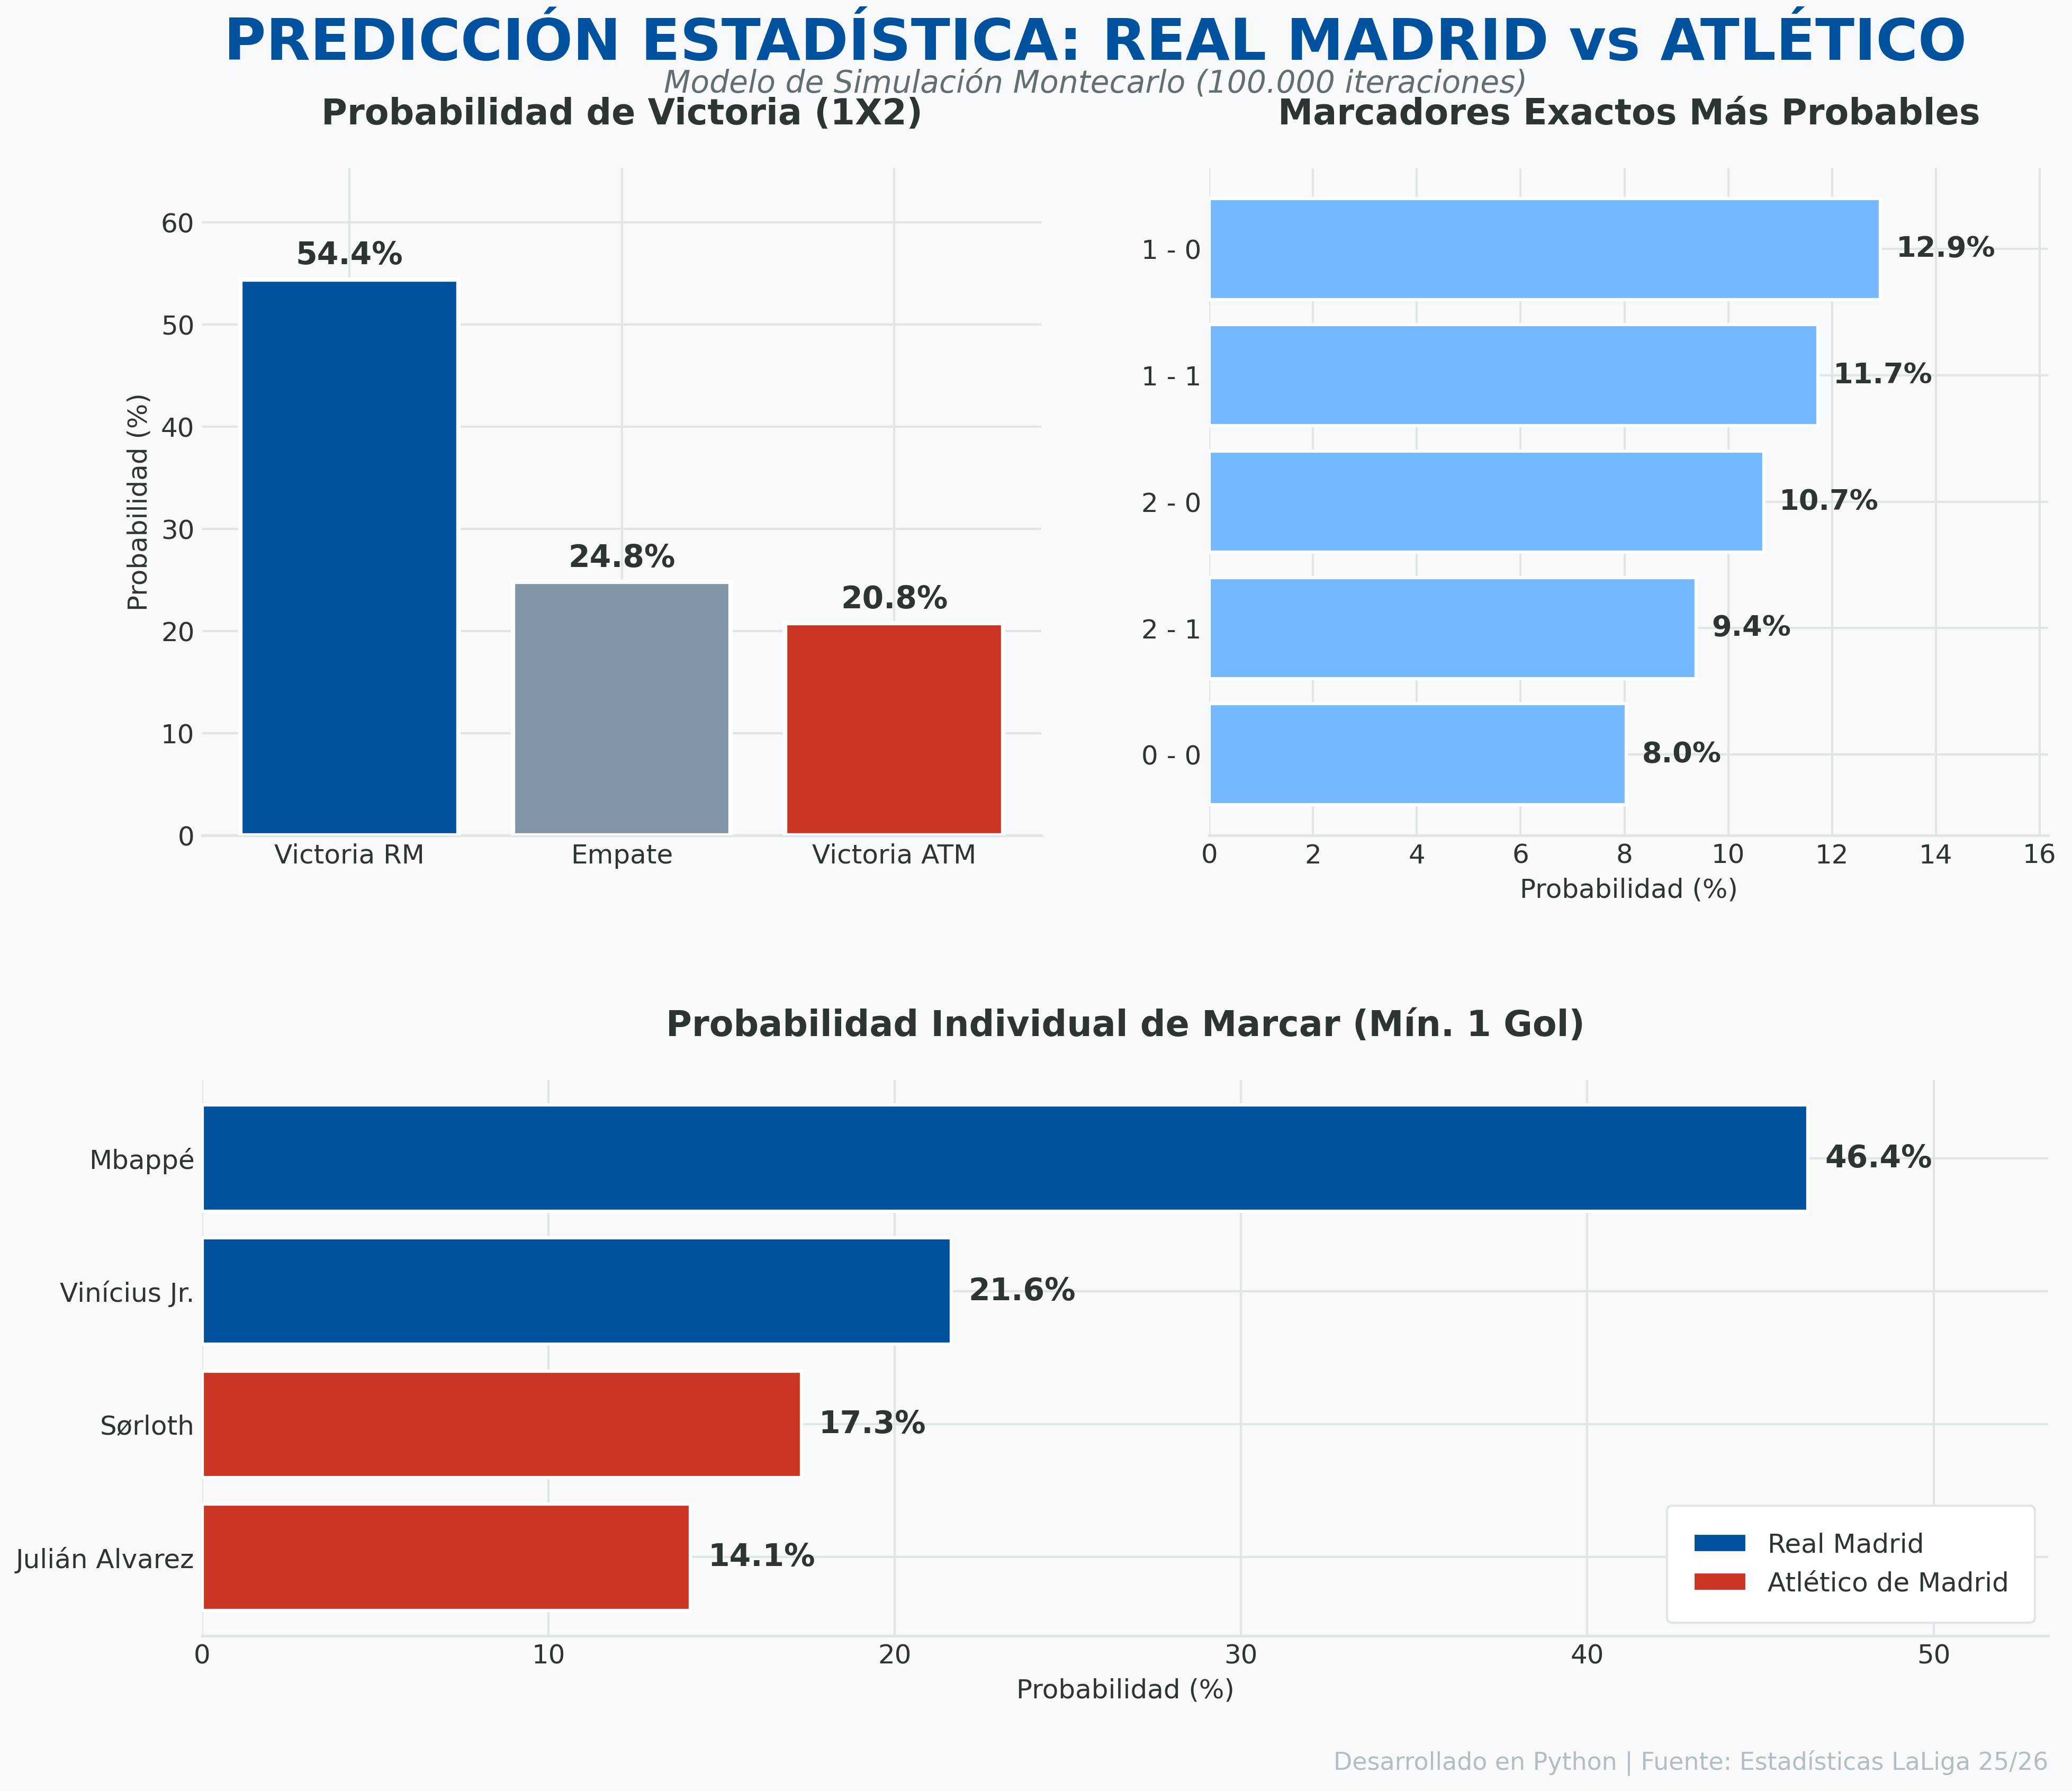


¡Análisis completado! Infografía generada como 'Derbi_Dashboard_Definitivo.png'


In [ ]:
# =========================================================================
# ANÁLISIS PREDICTIVO Y DASHBOARD PREMIUM: REAL MADRID VS ATLÉTICO
# =========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

# =========================================================================
# 1. INGRESO DE DATOS Y CÁLCULO DE LAMBDAS
# =========================================================================
partidos_jugados = 28
mitad_partidos = partidos_jugados / 2

# Real Madrid (Local)
rm_gf_total, rm_gf_casa, rm_gc_total = 60, 33, 24
rm_jugadores = {'Mbappé': 23, 'Vinícius Jr.': 9}

# Atlético de Madrid (Visitante)
atm_gf_total, atm_gf_fuera, atm_gc_total = 47, 13, 25
atm_jugadores = {'Sørloth': 10, 'Julián Alvarez': 8}

# Lambdas (Fuerzas ofensivas/defensivas)
lambda_rm = ((rm_gf_casa / mitad_partidos) + (atm_gc_total / partidos_jugados)) / 2
lambda_atm = ((atm_gf_fuera / mitad_partidos) + (rm_gc_total / partidos_jugados)) / 2

# =========================================================================
# 2. SIMULACIÓN DE MONTECARLO (100.000 iteraciones)
# =========================================================================
np.random.seed(2026)
n_simulaciones = 100000

sim_rm = np.random.poisson(lambda_rm, n_simulaciones)
sim_atm = np.random.poisson(lambda_atm, n_simulaciones)

# =========================================================================
# 3. EXTRACCIÓN DE DATOS PARA EL DASHBOARD
# =========================================================================
# A) Probabilidades 1X2
prob_1 = np.mean(sim_rm > sim_atm) * 100
prob_X = np.mean(sim_rm == sim_atm) * 100
prob_2 = np.mean(sim_rm < sim_atm) * 100

df_1x2 = pd.DataFrame({
    'Resultado': ['Victoria RM', 'Empate', 'Victoria ATM'],
    'Probabilidad': [prob_1, prob_X, prob_2],
    'Color': ['#00529F', '#8395A7', '#CB3524'] # Azul Navy, Gris, Rojo
})

# B) Top 5 Resultados Exactos
df_resultados = pd.DataFrame({'RM': sim_rm, 'ATM': sim_atm})
top_resultados = df_resultados.value_counts().head(5).reset_index(name='Frecuencia')
top_resultados['Probabilidad'] = (top_resultados['Frecuencia'] / n_simulaciones) * 100
top_resultados['Etiqueta'] = top_resultados['RM'].astype(str) + " - " + top_resultados['ATM'].astype(str)
top_resultados = top_resultados.sort_values('Probabilidad', ascending=True)

# C) Probabilidad de Goleadores
datos_goleadores = []
for jugador, goles in rm_jugadores.items():
    l_indiv = lambda_rm * (goles / rm_gf_total)
    prob = (1 - poisson.pmf(0, l_indiv)) * 100
    datos_goleadores.append({'Jugador': jugador, 'Probabilidad': prob, 'Equipo': 'Real Madrid', 'Color': '#00529F'})

for jugador, goles in atm_jugadores.items():
    l_indiv = lambda_atm * (goles / atm_gf_total)
    prob = (1 - poisson.pmf(0, l_indiv)) * 100
    datos_goleadores.append({'Jugador': jugador, 'Probabilidad': prob, 'Equipo': 'Atlético', 'Color': '#CB3524'})

df_jugadores = pd.DataFrame(datos_goleadores).sort_values('Probabilidad', ascending=True)

# =========================================================================
# 4. CONFIGURACIÓN VISUAL (Light Mode Corporativo)
# =========================================================================
plt.style.use('default')
color_fondo = '#F8F9FA'
color_texto = '#2D3436'
color_grid = '#DFE6E9'

sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": color_fondo,
    "figure.facecolor": color_fondo,
    "grid.color": color_grid,
    "grid.linestyle": "-",
    "axes.edgecolor": color_fondo,
    "text.color": color_texto,
    "axes.labelcolor": color_texto,
    "xtick.color": color_texto,
    "ytick.color": color_texto
})

# =========================================================================
# 5. CREACIÓN DEL LIENZO Y GRÁFICAS
# =========================================================================
fig = plt.figure(figsize=(15, 12), dpi=300)
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.4, wspace=0.2)

# Títulos
fig.suptitle('PREDICCIÓN ESTADÍSTICA: REAL MADRID vs ATLÉTICO',
             fontsize=26, fontweight='900', color='#00529F', y=0.96)
fig.text(0.5, 0.92, 'Modelo de Simulación Montecarlo (100.000 iteraciones)',
         ha='center', fontsize=14, color='#636E72', style='italic')

# --- GRÁFICO 1: PROBABILIDAD 1X2 ---
ax0 = fig.add_subplot(gs[0, 0])
bars0 = ax0.bar(df_1x2['Resultado'], df_1x2['Probabilidad'], color=df_1x2['Color'], edgecolor='white', linewidth=2, zorder=3)
ax0.set_title('Probabilidad de Victoria (1X2)', fontsize=16, fontweight='bold', pad=20)
ax0.set_ylabel('Probabilidad (%)', fontsize=12)
ax0.set_ylim(0, df_1x2['Probabilidad'].max() * 1.2)

for bar in bars0:
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{bar.get_height():.1f}%", ha='center', color=color_texto, fontweight='bold', fontsize=14)

# --- GRÁFICO 2: RESULTADOS EXACTOS ---
ax1 = fig.add_subplot(gs[0, 1])
bars1 = ax1.barh(top_resultados['Etiqueta'], top_resultados['Probabilidad'], color='#74B9FF', edgecolor='white', linewidth=1.5, zorder=3)
ax1.set_title('Marcadores Exactos Más Probables', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Probabilidad (%)', fontsize=12)
ax1.set_xlim(0, top_resultados['Probabilidad'].max() * 1.25)

for bar in bars1:
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va='center', color=color_texto, fontweight='bold', fontsize=13)

# --- GRÁFICO 3: GOLEADORES CON LEYENDA ---
ax2 = fig.add_subplot(gs[1, :])
bars2 = ax2.barh(df_jugadores['Jugador'], df_jugadores['Probabilidad'], color=df_jugadores['Color'], edgecolor='white', linewidth=1.5, zorder=3)
ax2.set_title('Probabilidad Individual de Marcar (Mín. 1 Gol)', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Probabilidad (%)', fontsize=12)
ax2.set_xlim(0, df_jugadores['Probabilidad'].max() * 1.15)

for bar in bars2:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va='center', color=color_texto, fontweight='bold', fontsize=14)

# Leyenda
elementos_leyenda = [
    Patch(facecolor='#00529F', edgecolor='white', label='Real Madrid'),
    Patch(facecolor='#CB3524', edgecolor='white', label='Atlético de Madrid')
]
ax2.legend(handles=elementos_leyenda, loc='lower right', fontsize=12, facecolor='white', edgecolor=color_grid, framealpha=1, borderpad=1)

# --- LIMPIEZA VISUAL ---
fig.text(0.9, 0.04, 'Desarrollado en Python | Fuente: Estadísticas LaLiga 25/26', ha='right', fontsize=11, color='#B2BEC3')

for ax in [ax0, ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(color_grid)
    ax.tick_params(axis='both', length=0, labelsize=12)
    ax.grid(axis='x', zorder=0, color=color_grid)
    if ax == ax0:
        ax.grid(axis='y', zorder=0, color=color_grid)

# =========================================================================
# 6. GUARDAR Y MOSTRAR
# =========================================================================
plt.savefig('Derbi_Dashboard_Definitivo.png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=300)
plt.show()

print("\n¡Análisis completado! Infografía generada como 'Derbi_Dashboard_Definitivo.png'")